In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.feature_selection import RFECV

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [3]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/almasbegum/software-defect-jm1/jm1.csv
/kaggle/input/datasets/almasbegum/software-defect-jm1/ReadMe.txt
/kaggle/input/datasets/almasbegum/software-defect-jm1/jm1.arff


In [4]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv(
    "/kaggle/input/datasets/almasbegum/software-defect-jm1/jm1.csv",
    na_values="?"
)

print(df.shape)

df.head()

(10885, 22)


,loc,v(g),ev(g),iv(g),n,v,l,d,i,e,...,lOCode,lOComment,lOBlank,locCodeAndComment,uniq_Op,uniq_Opnd,total_Op,total_Opnd,branchCount,defects
0,1.1,1.4,1.4,1.4,1.3,1.30,1.30,1.30,1.30,1.30,...,2,2,2,2,1.2,1.2,1.2,1.2,1.4,False
1,1.0,1.0,1.0,1.0,1.0,1.00,1.00,1.00,1.00,1.00,...,1,1,1,1,1.0,1.0,1.0,1.0,1.0,True
2,72.0,7.0,1.0,6.0,198.0,1134.13,0.05,20.31,55.85,23029.10,...,51,10,8,1,17.0,36.0,112.0,86.0,13.0,True
3,190.0,3.0,1.0,3.0,600.0,4348.76,0.06,17.06,254.87,74202.67,...,129,29,28,2,17.0,135.0,329.0,271.0,5.0,True
4,37.0,4.0,1.0,4.0,126.0,599.12,0.06,17.19,34.86,10297.30,...,28,1,6,0,11.0,16.0,76.0,50.0,7.0,True


In [5]:
# Check data types
print(df.dtypes)

# Convert all feature columns to numeric
feature_cols = df.columns.drop("defects")

df[feature_cols] = df[feature_cols].apply(
    pd.to_numeric,
    errors="coerce"
)

print(df.dtypes)

loc                  float64
v(g)                 float64
ev(g)                float64
iv(g)                float64
n                    float64
v                    float64
l                    float64
d                    float64
i                    float64
e                    float64
b                    float64
t                    float64
lOCode                 int64
lOComment              int64
lOBlank                int64
locCodeAndComment      int64
uniq_Op              float64
uniq_Opnd            float64
total_Op             float64
total_Opnd           float64
branchCount          float64
defects                 bool
dtype: object
loc                  float64
v(g)                 float64
ev(g)                float64
iv(g)                float64
n                    float64
v                    float64
l                    float64
d                    float64
i                    float64
e                    float64
b                    float64
t                    float64


In [14]:
# Features and target

X = df.drop(columns=["defects"])
y = df["defects"].astype(int)

print("X Shape:", X.shape)
print("y Shape:", y.shape)
print(y.value_counts())

X Shape: (10885, 21)
y Shape: (10885,)
defects
0    8779
1    2106
Name: count, dtype: int64


In [9]:
print(df.select_dtypes(include=['object']).columns)

Index([], dtype='object')


In [12]:
for col in df.columns:
    if (df[col].astype(str) == '?').sum() > 0:
        print(col, (df[col].astype(str) == '?').sum())

In [ ]:
data types

In [8]:
print(df.dtypes)

loc                  float64
v(g)                 float64
ev(g)                float64
iv(g)                float64
n                    float64
v                    float64
l                    float64
d                    float64
i                    float64
e                    float64
b                    float64
t                    float64
lOCode                 int64
lOComment              int64
lOBlank                int64
locCodeAndComment      int64
uniq_Op              float64
uniq_Opnd            float64
total_Op             float64
total_Opnd           float64
branchCount          float64
defects                 bool
dtype: object


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (8708, 21)
Testing : (2177, 21)


In [28]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFECV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Missing value imputation
imputer = SimpleImputer(strategy="median")

X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)

# Feature scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled = scaler.transform(X_test_imp)

# RFECV
rfecv = RFECV(
    estimator=RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    step=1,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

X_train_selected = rfecv.fit_transform(X_train_scaled, y_train)
X_test_selected = rfecv.transform(X_test_scaled)

print("Optimal Features :", rfecv.n_features_)

Optimal Features : 13


In [29]:
selected_features = X.columns[rfecv.support_]

print("Selected Features:")
for feature in selected_features:
    print(feature)

print("\nRemoved Feature:")
removed_features = X.columns[~rfecv.support_]
for feature in removed_features:
    print(feature)

Selected Features:
loc
iv(g)
n
v
d
i
e
t
lOCode
lOBlank
total_Op
total_Opnd
branchCount

Removed Feature:
v(g)
ev(g)
l
b
lOComment
locCodeAndComment
uniq_Op
uniq_Opnd


In [ ]:
model definition

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        ),

    "Support Vector Machine":
        SVC(
            kernel='rbf',
            probability=True,
            class_weight="balanced",
            random_state=42
        ),

    "Naive Bayes":
        GaussianNB(),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            n_estimators=200,
            random_state=42
        ),

    "XGBoost":
        XGBClassifier(
            eval_metric='logloss',
            random_state=42
        )
}

In [20]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

results = []

trained_models = {}

for name, model in models.items():

    model.fit(X_train_selected, y_train)

    trained_models[name] = model

    pred = model.predict(X_test_selected)

    if hasattr(model, "predict_proba"):
        prob = model.predict_proba(X_test_selected)[:,1]
        auc = roc_auc_score(y_test, prob)
    else:
        auc = np.nan

    results.append({

        "Model":name,

        "Accuracy":
            accuracy_score(y_test,pred),

        "Precision":
            precision_score(y_test,pred),

        "Recall":
            recall_score(y_test,pred),

        "F1 Score":
            f1_score(y_test,pred),

        "ROC-AUC":
            auc
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.696831,0.335172,0.577197,0.424084,0.698027
1,Support Vector Machine,0.711989,0.346269,0.551069,0.425298,0.698137
2,Naive Bayes,0.797428,0.454955,0.239905,0.314152,0.676063
3,Random Forest,0.808911,0.512315,0.247031,0.333333,0.729141
4,Gradient Boosting,0.804777,0.485714,0.161520,0.242424,0.724875
5,XGBoost,0.801102,0.470588,0.228029,0.307200,0.717280


In [21]:
results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
)

results_df.reset_index(drop=True,inplace=True)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Support Vector Machine,0.711989,0.346269,0.551069,0.425298,0.698137
1,Logistic Regression,0.696831,0.335172,0.577197,0.424084,0.698027
2,Random Forest,0.808911,0.512315,0.247031,0.333333,0.729141
3,Naive Bayes,0.797428,0.454955,0.239905,0.314152,0.676063
4,XGBoost,0.801102,0.470588,0.228029,0.307200,0.717280
5,Gradient Boosting,0.804777,0.485714,0.161520,0.242424,0.724875


In [22]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

for name, model in models.items():

    scores = cross_validate(

        model,

        X_train_selected,

        y_train,

        cv=cv,

        scoring=[
            "accuracy",
            "precision",
            "recall",
            "f1",
            "roc_auc"
        ]
    )

    cv_results.append({

        "Model":name,

        "Accuracy":
            scores["test_accuracy"].mean(),

        "Precision":
            scores["test_precision"].mean(),

        "Recall":
            scores["test_recall"].mean(),

        "F1 Score":
            scores["test_f1"].mean(),

        "ROC AUC":
            scores["test_roc_auc"].mean()

    })

cv_df = pd.DataFrame(cv_results)

cv_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.706132,0.348151,0.593472,0.438720,0.719817
1,Support Vector Machine,0.720717,0.361744,0.578635,0.444985,0.721296
2,Naive Bayes,0.803283,0.482005,0.224926,0.306621,0.696474
3,Random Forest,0.817868,0.569621,0.243917,0.341365,0.752162
4,Gradient Boosting,0.811552,0.543272,0.171513,0.259896,0.738842
5,XGBoost,0.810059,0.518290,0.254006,0.340579,0.725300


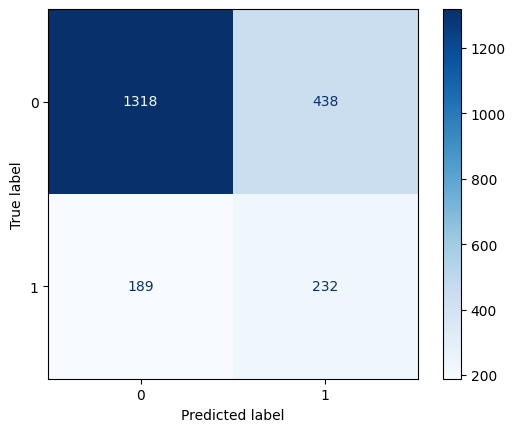

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay

best_model = trained_models["Support Vector Machine"]

ConfusionMatrixDisplay.from_estimator(

    best_model,

    X_test_selected,

    y_test,

    cmap="Blues"

)

plt.show()

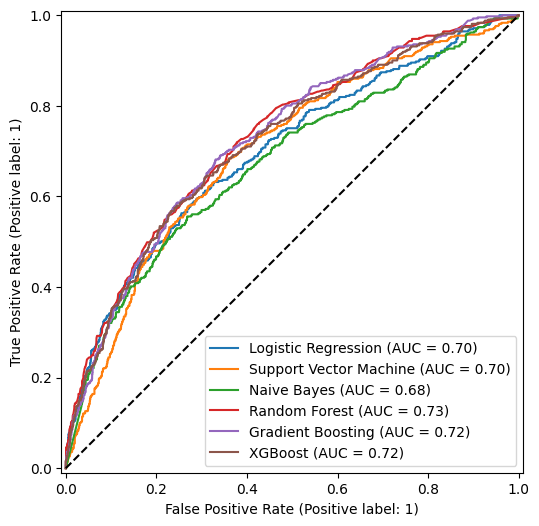

In [24]:
from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(8,6))

for name, model in trained_models.items():

    if hasattr(model,"predict_proba"):

        RocCurveDisplay.from_estimator(

            model,

            X_test_selected,

            y_test,

            name=name,

            ax=plt.gca()

        )

plt.plot([0,1],[0,1],'k--')

plt.show()

In [25]:
feature_table = pd.DataFrame({

    "Feature":X.columns,

    "Selected":rfecv.support_,

    "Ranking":rfecv.ranking_

})

feature_table.sort_values(

    by="Ranking",

    inplace=True

)

feature_table

,Feature,Selected,Ranking
0,loc,True,1
1,v(g),True,1
2,ev(g),True,1
3,iv(g),True,1
4,n,True,1
5,v,True,1
6,l,True,1
7,d,True,1
8,i,True,1
9,e,True,1


In [26]:
results_df.to_csv(

    "Results_RFECV.csv",

    index=False

)

cv_df.to_csv(

    "CrossValidation_RFECV.csv",

    index=False

)

feature_table.to_csv(

    "Selected_Features.csv",

    index=False

)

print("Files Saved Successfully")

Files Saved Successfully


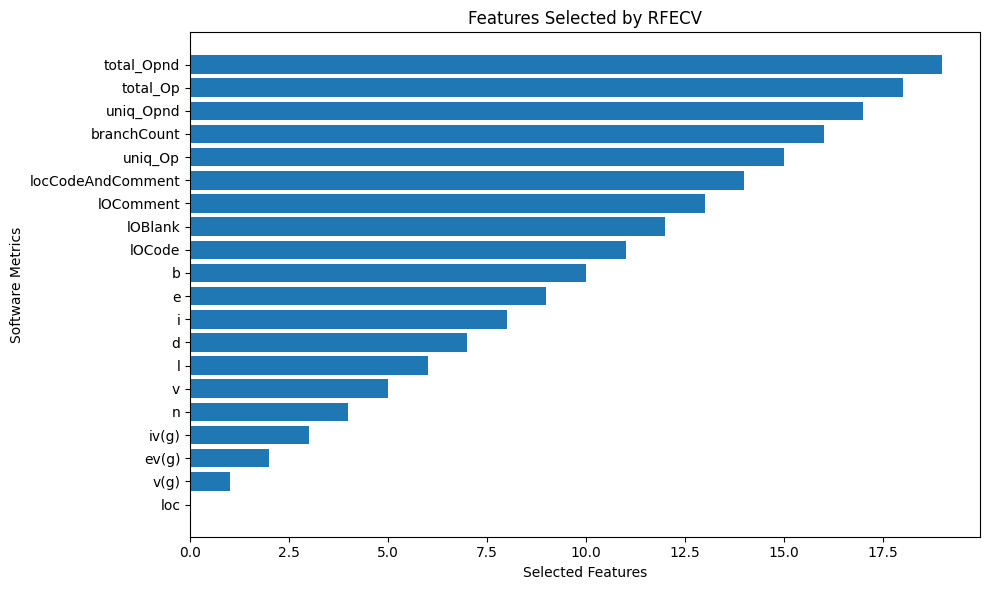

In [27]:
import matplotlib.pyplot as plt

selected = feature_table[feature_table["Selected"]==True]

plt.figure(figsize=(10,6))

plt.barh(

    selected["Feature"],

    range(len(selected))

)

plt.xlabel("Selected Features")

plt.ylabel("Software Metrics")

plt.title("Features Selected by RFECV")

plt.tight_layout()

plt.show()